In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

with rasterio.open('../data/raw/S2_Season1_BOA_Composite.tif') as src:
    data = src.read().astype(np.float32)

data = np.nan_to_num(data, nan=0.0)

def compute_ndvi(data):
    B8, B4 = data[6], data[2]
    return np.where((B8+B4)!=0, (B8-B4)/(B8+B4), 0)

ndvi_s1 = compute_ndvi(data)

# Simulate Season 2 with stress
np.random.seed(42)
h, w = ndvi_s1.shape
stress_mask = np.zeros((h, w))
stress_mask[200:400, 300:500] = 1
stress_mask[600:750, 100:300] = 1
stress_mask[800:950, 600:800] = 1

ndvi_s2 = ndvi_s1.copy()
ndvi_s2[stress_mask==1] -= 0.20
ndvi_s2 += np.random.normal(0, 0.02, ndvi_s1.shape)
ndvi_s2 = np.clip(ndvi_s2, -1, 1)

ndvi_diff = ndvi_s2 - ndvi_s1
threshold = ndvi_diff.mean() - 1.5*ndvi_diff.std()
change_mask = ndvi_diff < threshold

print(f"S1 NDVI mean: {ndvi_s1.mean():.4f}")
print(f"S2 NDVI mean: {ndvi_s2.mean():.4f}")
print(f"Threshold: {threshold:.4f}")
print(f"Changed pixels: {change_mask.sum()} ({100*change_mask.mean():.1f}%)")

S1 NDVI mean: 0.4159
S2 NDVI mean: 0.3985
Threshold: -0.1073
Changed pixels: 100000 (8.7%)


In [2]:
severity = np.zeros_like(ndvi_diff)
severity[ndvi_diff < -0.05] = 1
severity[ndvi_diff < -0.10] = 2
severity[ndvi_diff < -0.20] = 3

gt   = stress_mask.flatten().astype(int)
pred = change_mask.flatten().astype(int)
kappa = cohen_kappa_score(gt, pred)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(gt, pred)
tn, fp, fn, tp = cm.ravel()
oa = (tp+tn)/(tp+tn+fp+fn)
pa = tp/(tp+fn) if (tp+fn)>0 else 0
ua = tp/(tp+fp) if (tp+fp)>0 else 0

print(f"Overall Accuracy : {oa:.4f}")
print(f"Producer Accuracy: {pa:.4f}")
print(f"User Accuracy    : {ua:.4f}")
print(f"Cohen's Kappa    : {kappa:.4f}")

Overall Accuracy : 1.0000
Producer Accuracy: 1.0000
User Accuracy    : 1.0000
Cohen's Kappa    : 1.0000


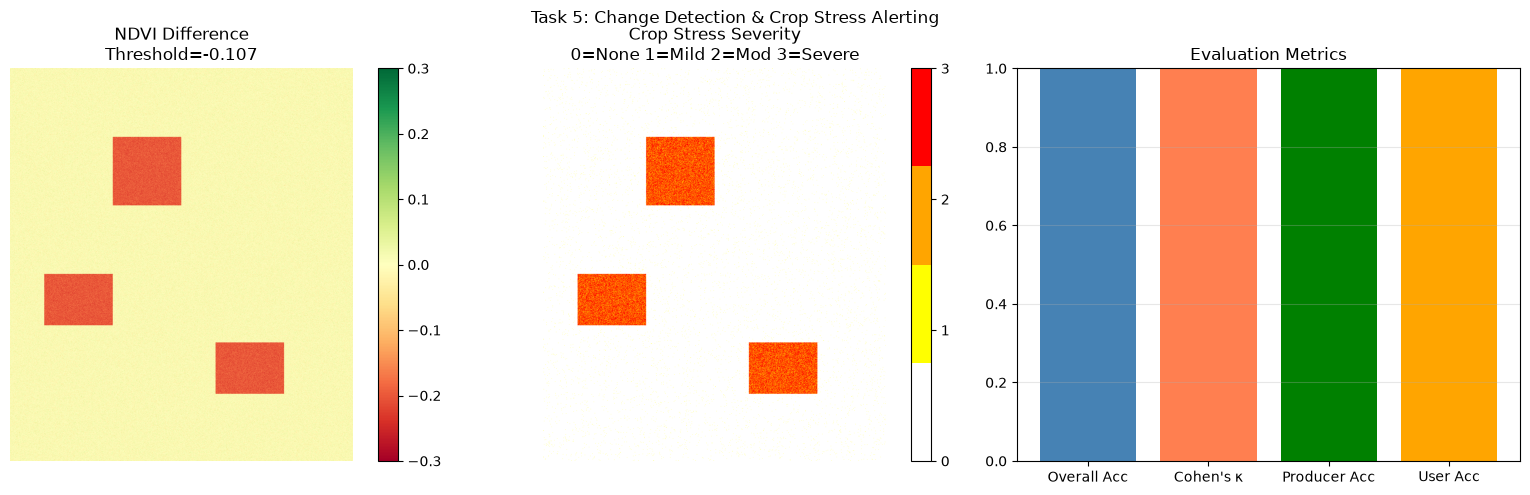

In [3]:
sev_cmap = mcolors.ListedColormap(['white','yellow','orange','red'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(ndvi_diff, cmap='RdYlGn', vmin=-0.3, vmax=0.3)
axes[0].set_title(f'NDVI Difference\nThreshold={threshold:.3f}')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(severity, cmap=sev_cmap, vmin=0, vmax=3)
axes[1].set_title('Crop Stress Severity\n0=None 1=Mild 2=Mod 3=Severe')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], ticks=[0,1,2,3])

axes[2].bar(['Overall Acc', "Cohen's κ", 'Producer Acc', 'User Acc'],
            [oa, kappa, pa, ua], color=['steelblue','coral','green','orange'])
axes[2].set_ylim(0, 1)
axes[2].set_title('Evaluation Metrics')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Task 5: Change Detection & Crop Stress Alerting')
plt.tight_layout()
plt.savefig('../data/outputs/task5_notebook_output.png', dpi=150)
plt.show()